In [1]:
# Import
import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
import datetime, os
from cartopy import crs as ccrs
from cartopy import feature as cfeature
# import seaborn as sns 
# from tabulate import tabulate
import sys
import re
from IPython.display import clear_output
import datetime
import textwrap
import csv

In [2]:
# Get current directory
current_directory = os.getcwd()
#print(current_directory)

# Specify the path to the folder you want to save data to 
Figures = os.path.join(current_directory, 'figures')
Files = os.path.join(current_directory, 'output_txt_files')
CSV = os.path.join(current_directory, 'csv_files')

#NOTE: copy and past permanent_txt_files from previous export

# Create directories only if they don't exist
os.makedirs(Figures, exist_ok=True)
os.makedirs(Files, exist_ok=True)
os.makedirs(CSV, exist_ok=True)

In [3]:
# labels corresponding to missing data
na_values = ['No observation', 'No observations', 'No Observation', 'No Observations',
             'no observation', 'no observations', 'None given', 'none given', 'None Given', 'none',
             'none recorded', 'not recorded', 'None recorded', 'Not given', 'not given', ' ', 'N.A.', 
             'Na', 'Does not say', 'N.A', 'Deos not say', 'N A', 'NA']

export_csv = 'logentries-export-2025-10-21.csv'

og_df = pd.read_csv(os.path.join(CSV, export_csv), na_values=na_values, low_memory=False)

# Combine using column names
og_df['DateTime'] = pd.to_datetime(og_df['Entry Date'] + ' ' + og_df['Local Time'], errors='coerce')
og_df.columns

Index(['ID', 'LogBook ID', 'Page', 'Entry Date', 'Local Time', 'Latitude',
       'Longitude', 'Depth', 'Depth Unit', 'Bottom', 'Current', 'Landmark',
       'Ship Heading/Course', 'Wind Direction', 'Wind Speed/Force',
       'Sea State', 'Cloud Cover', 'Weather', '2. Ship Heading/Course',
       '2. Wind Direction', '2. Wind Speed/Force', '2. Sea State',
       '2. Cloud Cover', '2. Weather', '3. Ship Heading', '3. Wind Direction',
       '3. Wind Speed/Force', '3. Sea State', '3. Cloud Cover', '3. Weather',
       'Ship Sightings', 'Instrumental Observations',
       'Miscellaneous Observations', 'DateTime'],
      dtype='object')

In [4]:
# labels corresponding to missing data
na_values = ['No observation', 'No observations', 'No Observation', 'No Observations',
             'no observation', 'no observations', 'None given', 'none given', 'None Given', 'none',
             'none recorded', 'not recorded', 'None recorded', 'Not given', 'not given', ' ', 'N.A.', 
             'Na', 'Does not say', 'N.A', 'Deos not say', 'N A', 'NA']

export_csv = 'logentries-export-2025-10-21.csv'

og_df = pd.read_csv(os.path.join(CSV, export_csv), na_values=na_values, low_memory=False)

# Combine using column names
og_df['DateTime'] = pd.to_datetime(og_df['Entry Date'] + ' ' + og_df['Local Time'], errors='coerce')
og_df.columns

Index(['ID', 'LogBook ID', 'Page', 'Entry Date', 'Local Time', 'Latitude',
       'Longitude', 'Depth', 'Depth Unit', 'Bottom', 'Current', 'Landmark',
       'Ship Heading/Course', 'Wind Direction', 'Wind Speed/Force',
       'Sea State', 'Cloud Cover', 'Weather', '2. Ship Heading/Course',
       '2. Wind Direction', '2. Wind Speed/Force', '2. Sea State',
       '2. Cloud Cover', '2. Weather', '3. Ship Heading', '3. Wind Direction',
       '3. Wind Speed/Force', '3. Sea State', '3. Cloud Cover', '3. Weather',
       'Ship Sightings', 'Instrumental Observations',
       'Miscellaneous Observations', 'DateTime'],
      dtype='object')

In [5]:
books_to_inspect = [
    'Alaska (Bark) 1880-1884',
    'Mercator(Ship) 1840-1843',
    'President (Bark) 1865-1869',
    'Lancer (Ship) 1865-1868',
    'Herald (Ship)  1834-1837',
    'Lapwing (Ship) 1860-1863'
]

subset_df = og_df[og_df['LogBook ID'].isin(books_to_inspect)]
#h_subset

In [6]:
# replace DateTime-strings that end with ' nan' with np.nan
df_dt = subset_df.copy()
df_dt.loc[df_dt.DateTime.astype(str).str.endswith(' nan'), 'DateTime'] = np.nan

In [7]:
# converting 'DateTime' column to actual DateTime and calling it "Entry Date Time"
df_dt['Entry Date Time'] = pd.to_datetime(df_dt.DateTime, format = '%Y-%m-%d %H:%M:%S')
# deleting row "DateTime"
df_dt.drop('DateTime',axis=1)

,ID,LogBook ID,Page,Entry Date,Local Time,Latitude,Longitude,Depth,Depth Unit,Bottom,...,3. Ship Heading,3. Wind Direction,3. Wind Speed/Force,3. Sea State,3. Cloud Cover,3. Weather,Ship Sightings,Instrumental Observations,Miscellaneous Observations,Entry Date Time
1852,134444,Herald (Ship) 1834-1837,73,1835-06-12,12:00:00,NaN,NaN,NaN,fathoms,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,At 1 PM sent a boat on board a fishing schoone...,1835-06-12 12:00:00
1853,134443,Herald (Ship) 1834-1837,73,1835-06-11,12:00:00,40 45 S,71 33 W,NaN,fathoms,NaN,...,NaN,E,light airs,NaN,NaN,calm,Saw a number of sails a steering various courses,NaN,NaN,1835-06-11 12:00:00
1854,134442,Herald (Ship) 1834-1837,73,1835-06-10,12:00:00,39 42 S,71 20 W,NaN,fathoms,NaN,...,NaN,W,moderate,NaN,NaN,fine and pleasant,Spoke with the Brig Dover from Denmark for Bos...,NaN,NaN,1835-06-10 12:00:00
1855,134441,Herald (Ship) 1834-1837,NaN,1837-04-16,12:00:00,NaN,NaN,NaN,fathoms,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1837-04-16 12:00:00
1856,134440,Herald (Ship) 1834-1837,NaN,1837-04-15,12:00:00,39 21 N,70 25 W,NaN,fathoms,NaN,...,NaN,W,strong,NaN,NaN,heavy,Saw two sails in sight to the North,NaN,NaN,1837-04-15 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39984,95373,Lancer (Ship) 1865-1868,NaN,1865-05-28,12:00:00,NaN,NaN,NaN,NaN,NaN,...,E by S,NE,Fine breezes,NaN,NaN,NaN,NaN,NaN,NaN,1865-05-28 12:00:00
39985,95372,Lancer (Ship) 1865-1868,NaN,1865-05-27,12:00:00,NaN,NaN,NaN,NaN,NaN,...,E by S,NaN,Strong breezes,NaN,NaN,NaN,NaN,NaN,NaN,1865-05-27 12:00:00
39986,95371,Lancer (Ship) 1865-1868,NaN,1865-05-26,12:00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1865-05-26 12:00:00
39987,95370,Lancer (Ship) 1865-1868,NaN,1865-05-25,12:00:00,NaN,NaN,NaN,NaN,NaN,...,E by S,NW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1865-05-25 12:00:00


In [8]:
from utils.cleaning import dms_to_decimal

df = df_dt.copy()
df['Latitude_decimal']=df['Latitude'].apply(dms_to_decimal)
df['Longitude_decimal']=df['Longitude'].apply(dms_to_decimal)

Saved: /home/finn.wimberly/Documents/whaling_logs/20251021_export/figures/inspect_Lapwing (Ship) 1860-1863_1860.png


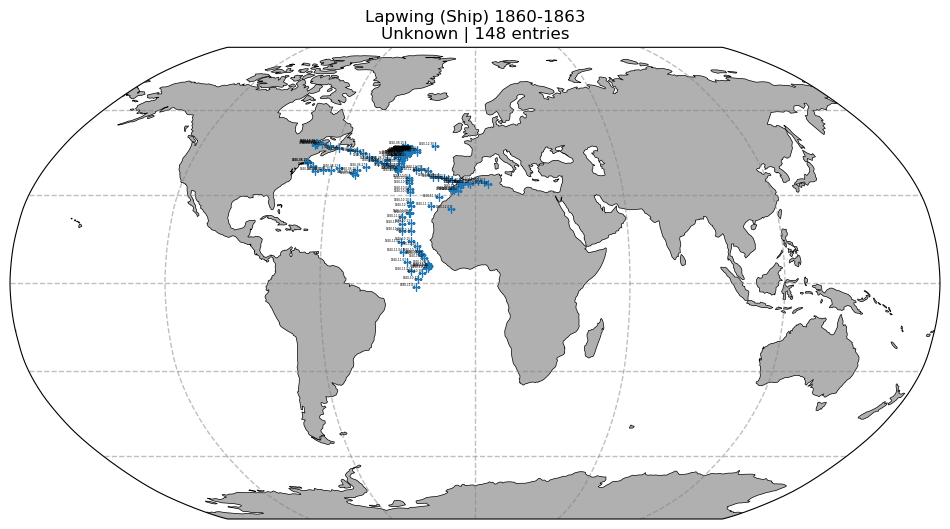

In [10]:
from utils.cleaning import plot_logbook

logbook = "Lapwing (Ship) 1860-1863"
year = 1860

_ = plot_logbook(
    df, logbook,
    years = year,
    annotate=True,                
    annotate_field= 'Entry Date',
    annotate_max=400,  
    figures_dir = Figures,
    filename=f"inspect_{logbook}_{year}.png",
    dpi=300,
)

Starting tasks for Sue to take care of:
- change date to correct year in 127545
- 1834 appears to have more eclectic errors we can deal with those later
- invert latitudes from S to N from 1835-05-10 to 1835-08-19
- invert latitudes from N to S from 1835-09-05 to 1835-10-30
- Most of 1836 and 1837 appear to be correct!